# vllm-bench: W250 vs W300 Analysis (Qwen3.5-397B-A17B)

Comparing power cap configurations on the same hardware with identical vLLM configs.

In [ ]:
import json
import glob
import csv
import os
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['figure.dpi'] = 120

# Resolve bench dir relative to this notebook's location
_nb_dir = Path(os.path.abspath('')).resolve()
if (_nb_dir / '../bench').is_dir():
    BENCH_DIR = str((_nb_dir / '../bench').resolve())
elif (_nb_dir / 'bench').is_dir():
    BENCH_DIR = str((_nb_dir / 'bench').resolve())
else:
    BENCH_DIR = 'bench'

PLOT_DIR = str((_nb_dir / 'plots').resolve()) if _nb_dir.name == 'notebooks' else str((_nb_dir / 'notebooks/plots').resolve())
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'BENCH_DIR: {BENCH_DIR}')
print(f'PLOT_DIR:  {PLOT_DIR}')

## 1. Load all benchmark results into a DataFrame

In [ ]:
rows = []
for f in sorted(glob.glob(f'{BENCH_DIR}/qwen35-397b-a17b-nvfp4_W*/qwen35-397b-a17b-nvfp4_random_*/openai-*.json')):
    with open(f) as fh:
        d = json.load(fh)
    # Extract watt from path
    p = Path(f)
    model_dir = p.parent.parent.name
    watt = int(model_dir.split('_W')[-1])
    rows.append({
        'watt': watt,
        'input_len': d['input_lens'][0],
        'output_len': d['output_lens'][0],
        'concurrency': d['max_concurrency'],
        'output_tps': d['output_throughput'],
        'peak_tps': d.get('max_output_tokens_per_s', 0),
        'total_tps': d['total_token_throughput'],
        'ttft_p50': d['p50_ttft_ms'],
        'ttft_p95': d['p95_ttft_ms'],
        'ttft_p99': d['p99_ttft_ms'],
        'tpot_p50': d['p50_tpot_ms'],
        'tpot_p95': d['p95_tpot_ms'],
        'tpot_p99': d['p99_tpot_ms'],
        'itl_p50': d['p50_itl_ms'],
        'e2el_p50': d['p50_e2el_ms'],
        'completed': d['completed'],
        'failed': d['failed'],
        'duration_s': d['duration'],
        'json_path': f,
    })

df = pd.DataFrame(rows).sort_values(['watt', 'input_len', 'concurrency']).reset_index(drop=True)
print(f'Loaded {len(df)} benchmark runs')
print(f'Watt configs: {sorted(df.watt.unique())}')
print(f'Input lengths: {sorted(df.input_len.unique())}')
df.head()

## 2. Load telemetry summaries

In [ ]:
telem_rows = []
for f in sorted(glob.glob(f'{BENCH_DIR}/qwen35-397b-a17b-nvfp4_W*/qwen35-397b-a17b-nvfp4_random_*/telemetry_summary.json')):
    with open(f) as fh:
        ts = json.load(fh)
    # Parse watt, input_len, concurrency from path components
    p = Path(f)
    model_dir = p.parent.parent.name  # e.g. qwen35-397b-a17b-nvfp4_W250
    run_dir = p.parent.name           # e.g. qwen35-397b-a17b-nvfp4_random_2048in_1024out_c72_W250
    watt = int(model_dir.split('_W')[-1])
    input_len = int(run_dir.split('_random_')[1].split('in_')[0])
    conc = int(run_dir.split('_c')[-1].split('_W')[0])
    ts['watt'] = watt
    ts['input_len'] = input_len
    ts['concurrency'] = conc
    telem_rows.append(ts)

df_telem = pd.DataFrame(telem_rows)
print(f'Loaded {len(df_telem)} telemetry summaries')

# Drop columns that overlap with benchmark df (except merge keys)
telem_drop = [c for c in df_telem.columns if c in df.columns and c not in ['watt', 'input_len', 'concurrency']]
df_telem = df_telem.drop(columns=telem_drop)
print(f'Dropped overlapping columns: {telem_drop}')

# Merge with benchmark results
df_full = df.merge(df_telem, on=['watt', 'input_len', 'concurrency'], how='left')
print(f'Merged: {len(df_full)} rows, {df_full.mean_power_w.notna().sum()} with telemetry')

## 3. Peak throughput comparison: W250 vs W300

In [4]:
# Find peak throughput per (watt, input_len)
peak = df_full.loc[df_full.groupby(['watt', 'input_len'])['output_tps'].idxmax()]
peak = peak[['watt', 'input_len', 'concurrency', 'output_tps', 'peak_tps', 'duration_s',
             'ttft_p50', 'tpot_p50', 'mean_power_w', 'max_power_w']].copy()

# Pivot for comparison
for metric in ['output_tps', 'concurrency', 'mean_power_w', 'duration_s']:
    pivot = peak.pivot(index='input_len', columns='watt', values=metric)
    if 250 in pivot.columns and 300 in pivot.columns:
        pivot['delta_%'] = ((pivot[300] - pivot[250]) / pivot[250] * 100).round(1)
    print(f'\n--- {metric} ---')
    display(pivot)


--- output_tps ---


watt,250,300,delta_%
input_len,,,
2048,1041.281011,1123.813448,7.9
4096,864.674089,908.004729,5.0
8192,615.913683,648.595794,5.3
16384,365.819258,386.974234,5.8
32768,204.516492,211.673868,3.5
65536,97.854272,102.250548,4.5



--- concurrency ---


watt,250,300,delta_%
input_len,,,
2048,72,64,-11.1
4096,96,64,-33.3
8192,80,72,-10.0
16384,48,48,0.0
32768,32,32,0.0
65536,16,16,0.0



--- mean_power_w ---


watt,250,300,delta_%
input_len,,,
2048,912.860647,1062.140970,16.4
4096,894.833930,1034.425568,15.6
8192,865.809590,991.493181,14.5
16384,838.172790,946.564122,12.9
32768,820.949473,913.166049,11.2
65536,842.358084,936.131072,11.1



--- duration_s ---


watt,250,300,delta_%
input_len,,,
2048,125.875723,116.631457,-7.3
4096,151.585437,144.351671,-4.8
8192,212.809041,202.085800,-5.0
16384,358.297157,338.709890,-5.5
32768,640.887191,619.216727,-3.4
65536,1339.461188,1281.870886,-4.3


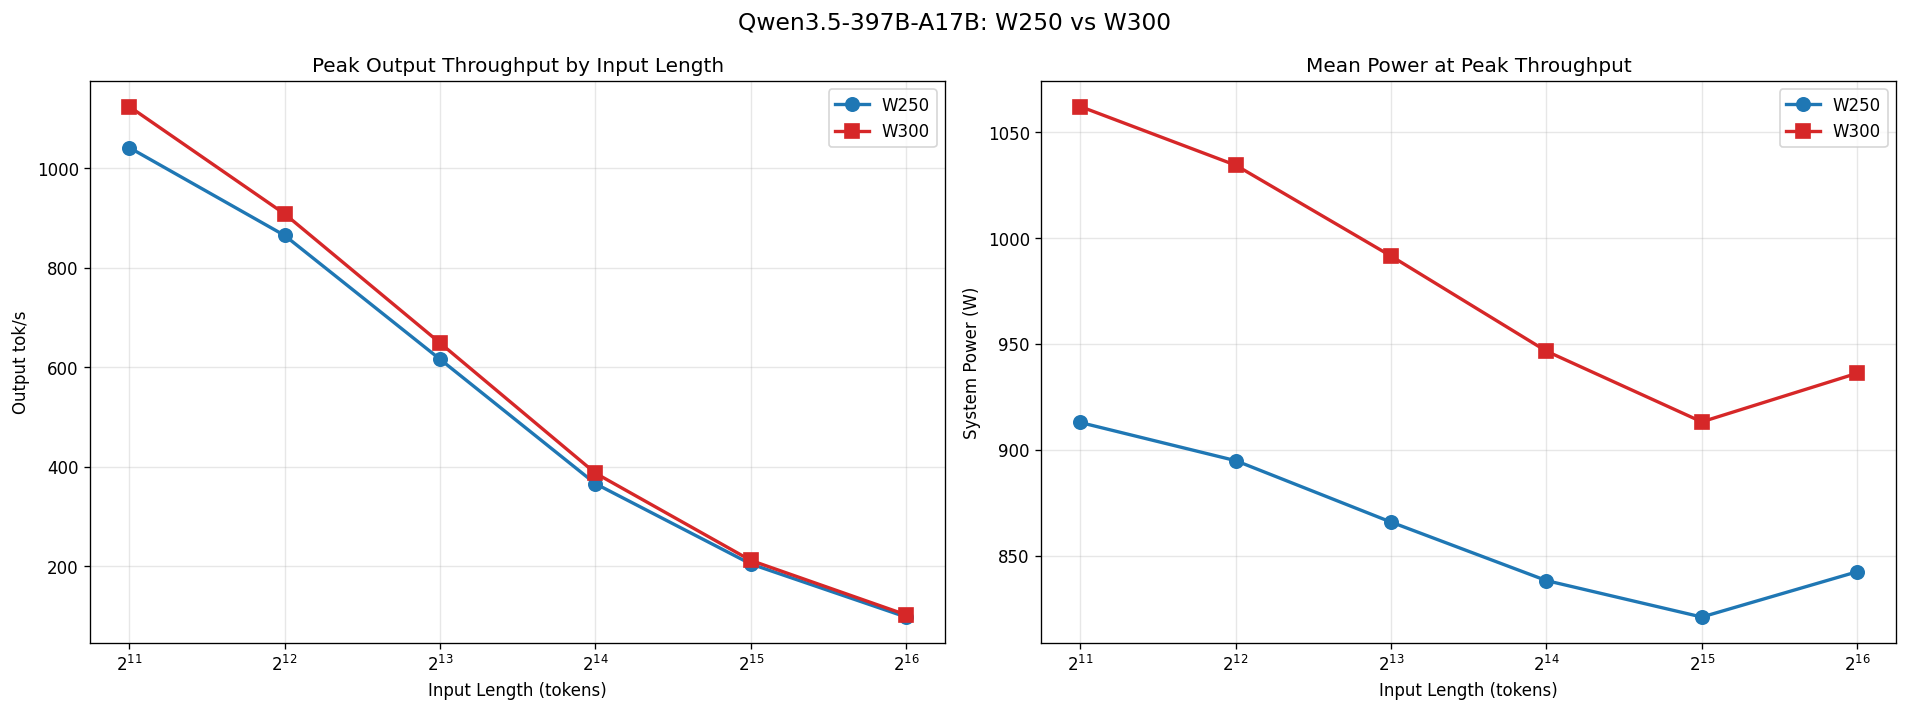

In [5]:
# Throughput comparison chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for watt, color, marker in [(250, 'tab:blue', 'o'), (300, 'tab:red', 's')]:
    p = peak[peak.watt == watt].sort_values('input_len')
    axes[0].plot(p.input_len, p.output_tps, f'{marker}-', color=color, linewidth=2, label=f'W{watt}', markersize=8)
    axes[1].plot(p.input_len, p.mean_power_w, f'{marker}-', color=color, linewidth=2, label=f'W{watt}', markersize=8)

axes[0].set_title('Peak Output Throughput by Input Length')
axes[0].set_xlabel('Input Length (tokens)')
axes[0].set_ylabel('Output tok/s')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log', base=2)

axes[1].set_title('Mean Power at Peak Throughput')
axes[1].set_xlabel('Input Length (tokens)')
axes[1].set_ylabel('System Power (W)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log', base=2)

fig.suptitle('Qwen3.5-397B-A17B: W250 vs W300', fontsize=14)
fig.tight_layout()
plt.show()

## 4. Efficiency analysis: tok/s per Watt

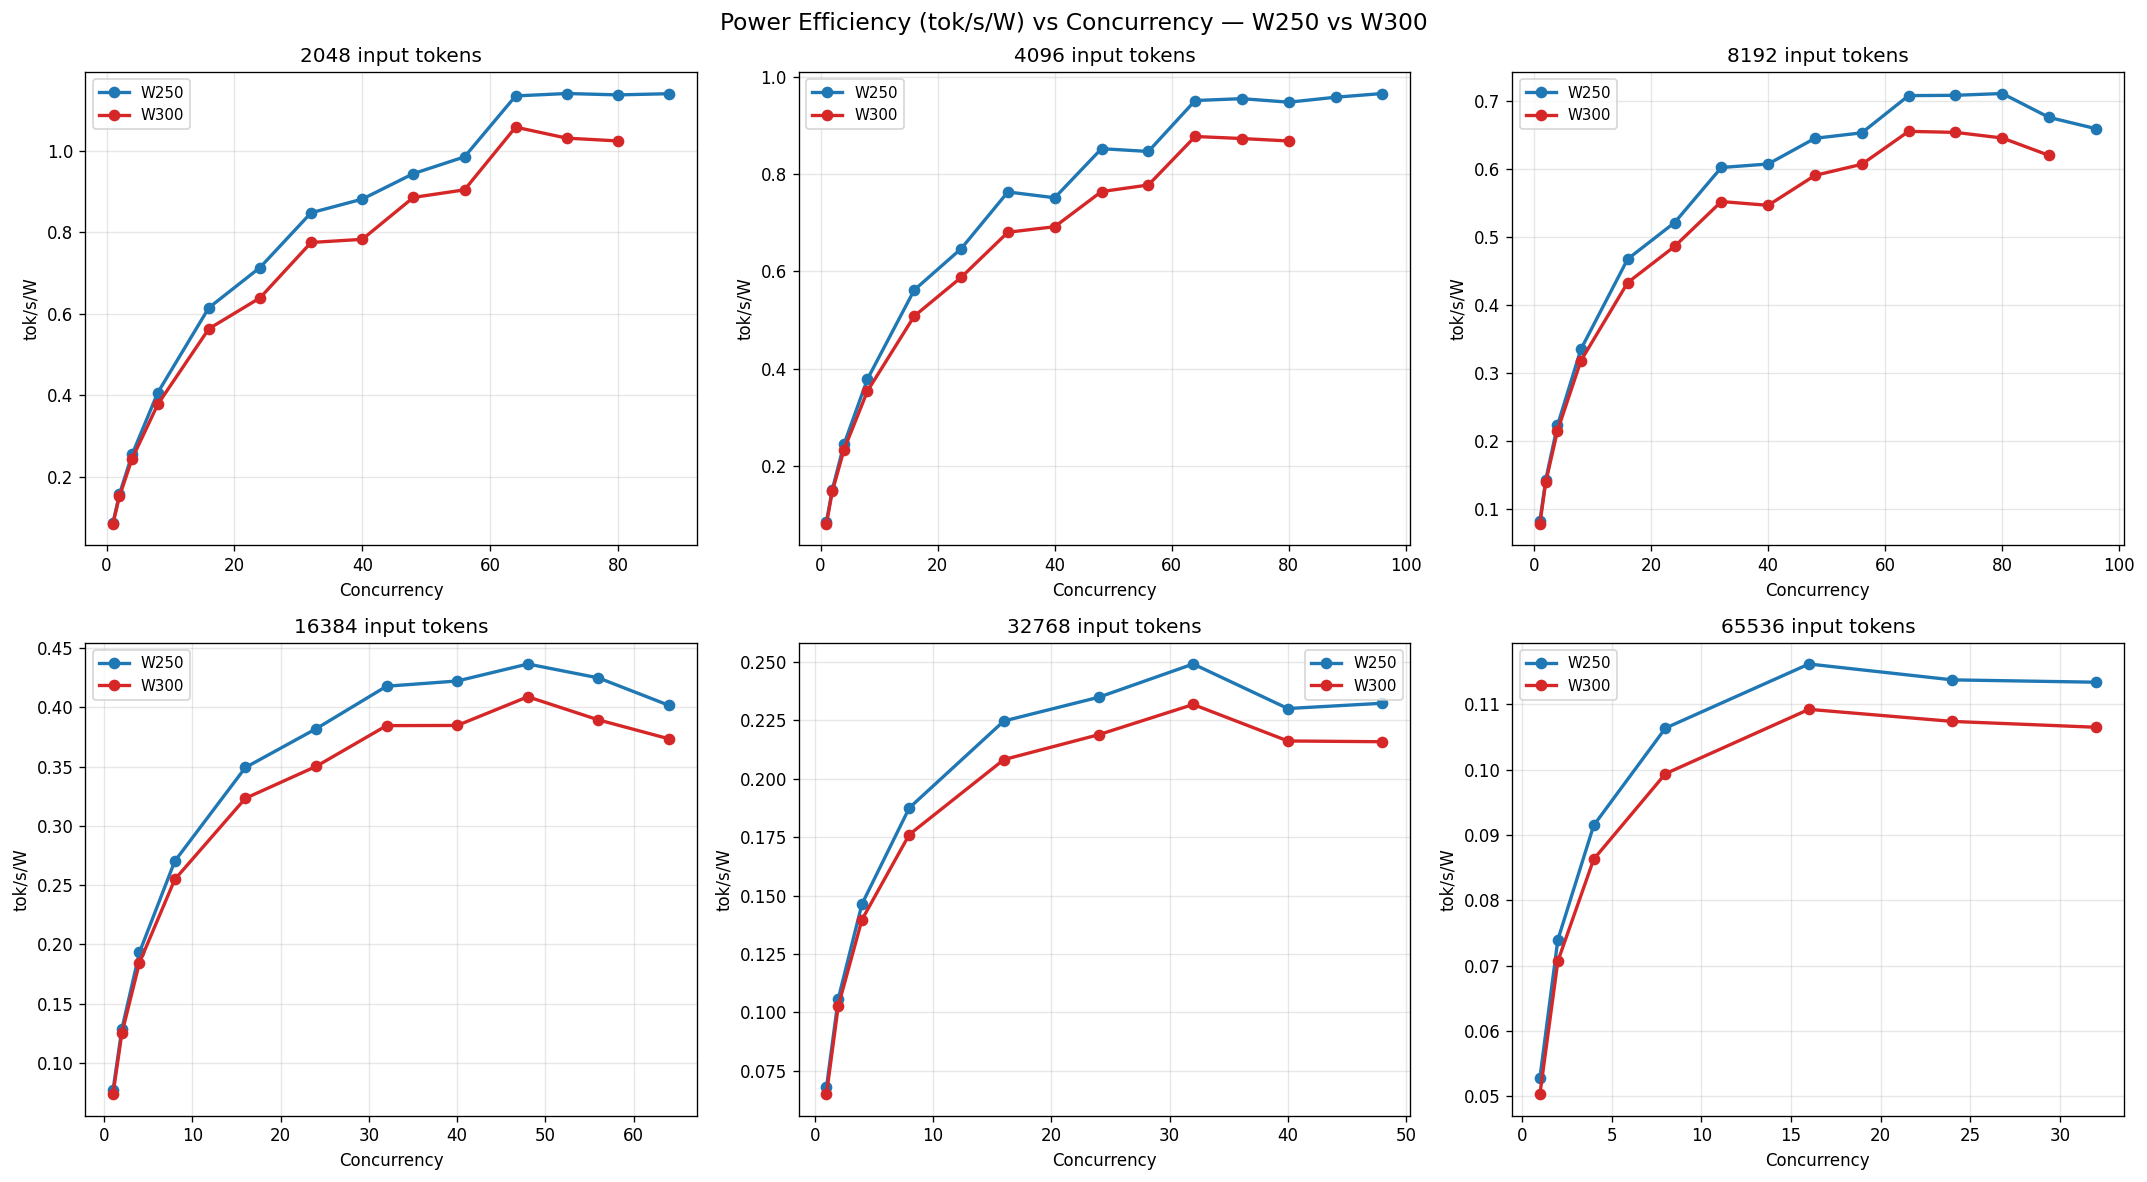

In [6]:
df_eff = df_full[df_full.mean_power_w.notna() & (df_full.mean_power_w > 0)].copy()
df_eff['efficiency'] = df_eff['output_tps'] / df_eff['mean_power_w']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Power Efficiency (tok/s/W) vs Concurrency — W250 vs W300', fontsize=14)

for idx, input_len in enumerate(sorted(df_eff.input_len.unique())):
    ax = axes.flat[idx]
    for watt, color in [(250, 'tab:blue'), (300, 'tab:red')]:
        subset = df_eff[(df_eff.watt == watt) & (df_eff.input_len == input_len)].sort_values('concurrency')
        if len(subset) > 0:
            ax.plot(subset.concurrency, subset.efficiency, 'o-', color=color, linewidth=2, label=f'W{watt}')
    ax.set_title(f'{input_len} input tokens')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('tok/s/W')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 5. Power dynamics during a single run: prefill vs decode

Does the GPU draw more power during the prefill phase (processing input tokens) than during decode (generating output tokens)? Let's look at the time-series telemetry for the peak throughput run.

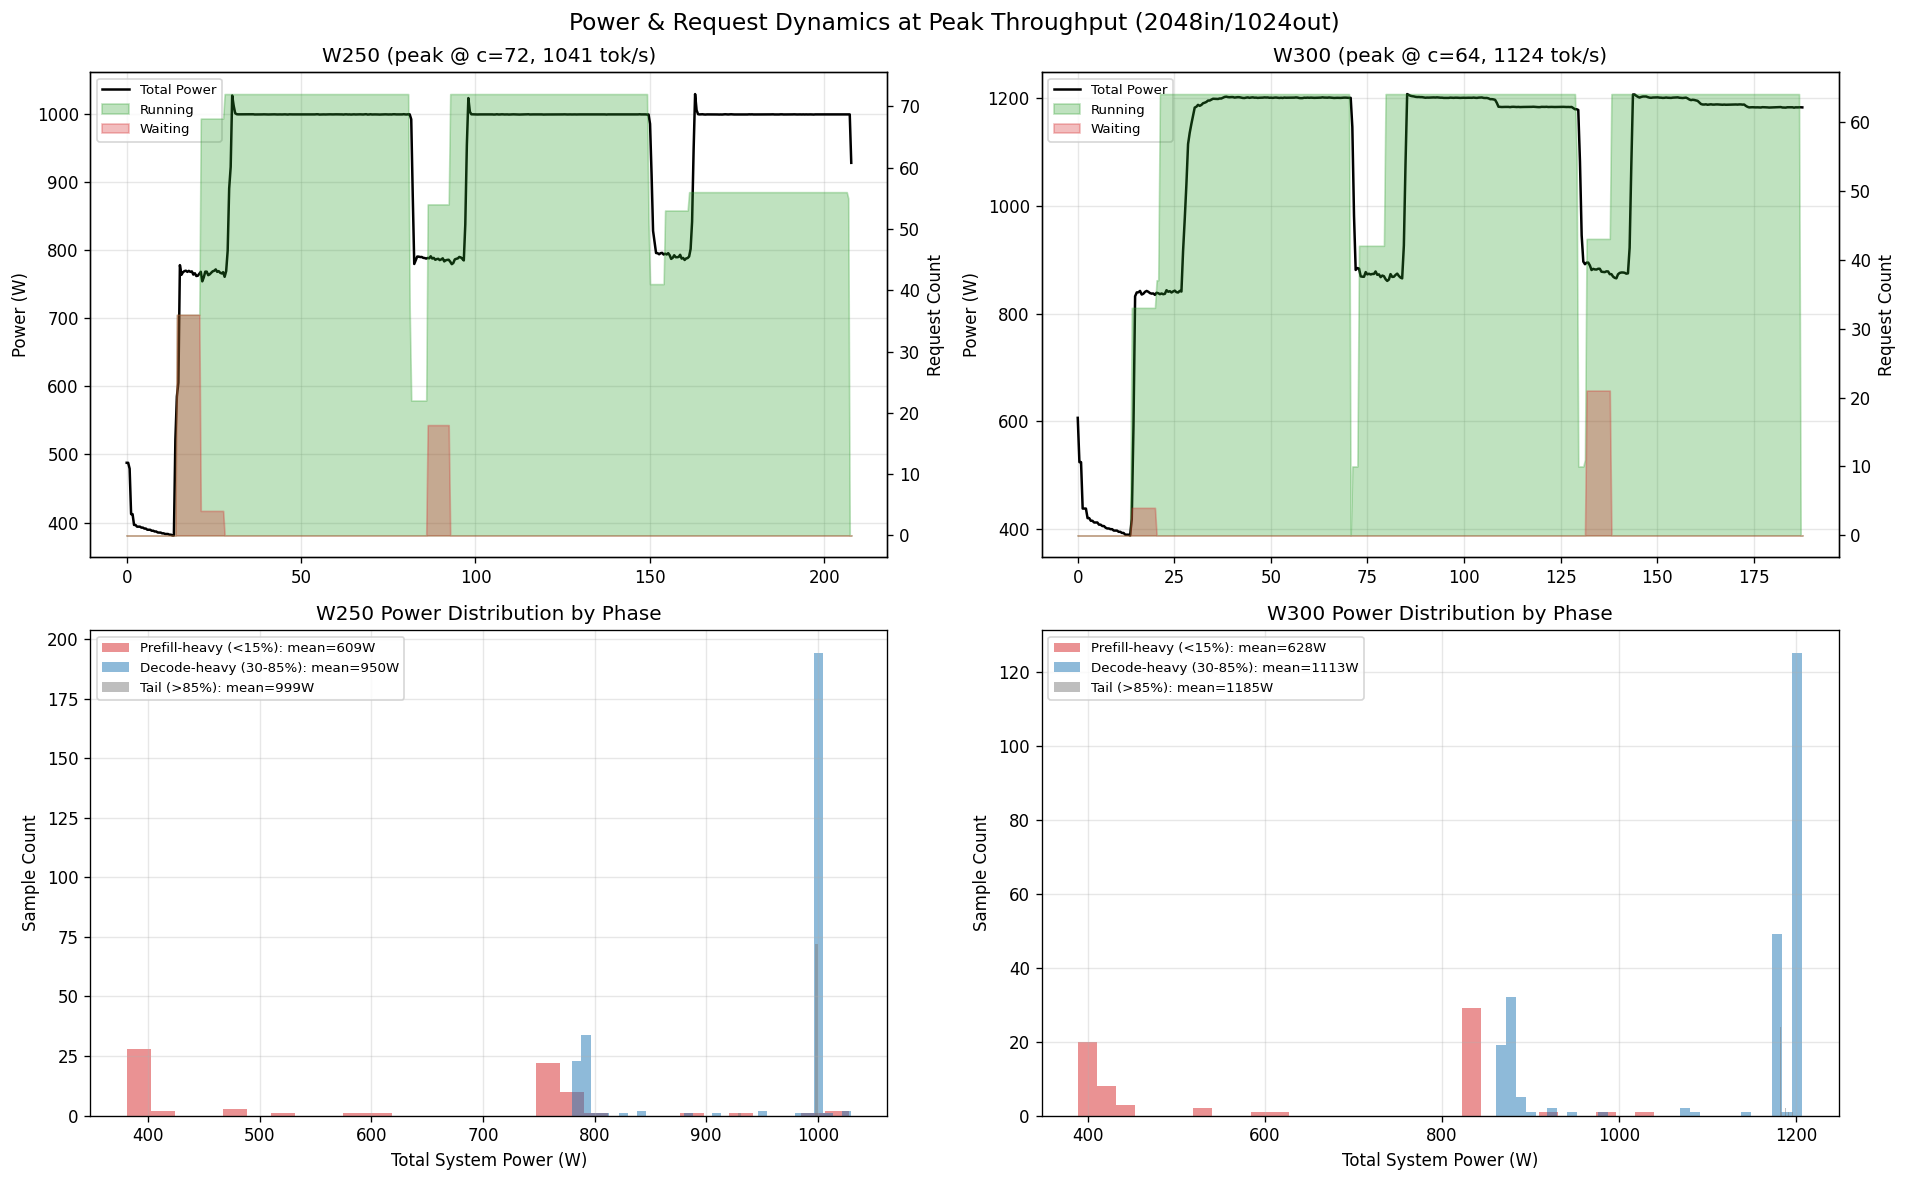

In [7]:
def load_telemetry_csv(csv_path):
    """Load a telemetry CSV into a DataFrame."""
    return pd.read_csv(csv_path)

# Compare power profiles at peak throughput for both watt configs
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Power & Request Dynamics at Peak Throughput (2048in/1024out)', fontsize=14)

for col_idx, watt in enumerate([250, 300]):
    # Find peak throughput run for 2048 input
    subset = df_full[(df_full.watt == watt) & (df_full.input_len == 2048)]
    best_idx = subset.output_tps.idxmax()
    best = subset.loc[best_idx]
    conc = int(best.concurrency)
    
    csv_path = f'{BENCH_DIR}/qwen35-397b-a17b-nvfp4_W{watt}/qwen35-397b-a17b-nvfp4_random_2048in_1024out_c{conc}_W{watt}/telemetry.csv'
    tel = load_telemetry_csv(csv_path)
    
    # Total power across 4 GPUs
    gpu_power_cols = [c for c in tel.columns if c.endswith('_power_w')]
    tel['total_power_w'] = tel[gpu_power_cols].sum(axis=1)
    
    # Top row: power + requests_running
    ax = axes[0, col_idx]
    ax.plot(tel.elapsed_s, tel.total_power_w, 'k-', linewidth=1.5, label='Total Power')
    ax.set_ylabel('Power (W)', color='k')
    ax.set_title(f'W{watt} (peak @ c={conc}, {best.output_tps:.0f} tok/s)')
    ax.grid(True, alpha=0.3)
    
    ax2 = ax.twinx()
    ax2.fill_between(tel.elapsed_s, tel.requests_running, alpha=0.3, color='tab:green', label='Running')
    ax2.fill_between(tel.elapsed_s, tel.requests_waiting, alpha=0.3, color='tab:red', label='Waiting')
    ax2.set_ylabel('Request Count')
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
    
    # Bottom row: power histogram split into phases
    ax = axes[1, col_idx]
    
    # Heuristic: "prefill-heavy" = first 15% of run, "decode-heavy" = middle 50-85%
    max_t = tel.elapsed_s.max()
    prefill_mask = tel.elapsed_s < max_t * 0.15
    decode_mask = (tel.elapsed_s > max_t * 0.30) & (tel.elapsed_s < max_t * 0.85)
    tail_mask = tel.elapsed_s > max_t * 0.85
    
    for mask, label, color in [
        (prefill_mask, 'Prefill-heavy (<15%)', 'tab:red'),
        (decode_mask, 'Decode-heavy (30-85%)', 'tab:blue'),
        (tail_mask, 'Tail (>85%)', 'tab:gray'),
    ]:
        vals = tel.loc[mask, 'total_power_w']
        if len(vals) > 0:
            ax.hist(vals, bins=30, alpha=0.5, color=color, label=f'{label}: mean={vals.mean():.0f}W')
    
    ax.set_xlabel('Total System Power (W)')
    ax.set_ylabel('Sample Count')
    ax.set_title(f'W{watt} Power Distribution by Phase')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Prefill vs decode power across input lengths

If prefill draws more power, the effect should be stronger with longer inputs (more tokens to process in the prefill phase).

In [8]:
# For each input length at W250, load the peak throughput run's telemetry
# and compare early (prefill-heavy) vs late (decode-heavy) power

phase_data = []

for input_len in sorted(df_full[df_full.watt == 250].input_len.unique()):
    subset = df_full[(df_full.watt == 250) & (df_full.input_len == input_len)]
    best_idx = subset.output_tps.idxmax()
    best = subset.loc[best_idx]
    conc = int(best.concurrency)
    
    csv_path = f'{BENCH_DIR}/qwen35-397b-a17b-nvfp4_W250/qwen35-397b-a17b-nvfp4_random_{input_len}in_1024out_c{conc}_W250/telemetry.csv'
    try:
        tel = load_telemetry_csv(csv_path)
        gpu_power_cols = [c for c in tel.columns if c.endswith('_power_w')]
        tel['total_power_w'] = tel[gpu_power_cols].sum(axis=1)
        
        max_t = tel.elapsed_s.max()
        prefill = tel[tel.elapsed_s < max_t * 0.15].total_power_w
        decode = tel[(tel.elapsed_s > max_t * 0.30) & (tel.elapsed_s < max_t * 0.85)].total_power_w
        
        phase_data.append({
            'input_len': input_len,
            'concurrency': conc,
            'prefill_mean_w': prefill.mean(),
            'prefill_max_w': prefill.max(),
            'decode_mean_w': decode.mean(),
            'decode_max_w': decode.max(),
            'delta_w': prefill.mean() - decode.mean(),
            'delta_pct': (prefill.mean() - decode.mean()) / decode.mean() * 100,
        })
    except FileNotFoundError:
        pass

df_phase = pd.DataFrame(phase_data)
display(df_phase.round(1))

,input_len,concurrency,prefill_mean_w,prefill_max_w,decode_mean_w,decode_max_w,delta_w,delta_pct
0,2048,72,608.8,1027.8,950.3,1029.9,-341.5,-35.9
1,4096,96,603.6,903.0,921.5,1027.0,-317.9,-34.5
2,8192,80,602.3,1024.5,867.5,1031.4,-265.2,-30.6
3,16384,48,589.2,1025.6,877.1,1029.2,-287.9,-32.8
4,32768,32,544.2,1012.9,875.4,1028.0,-331.2,-37.8
5,65536,16,534.8,1024.8,894.9,1028.5,-360.2,-40.2


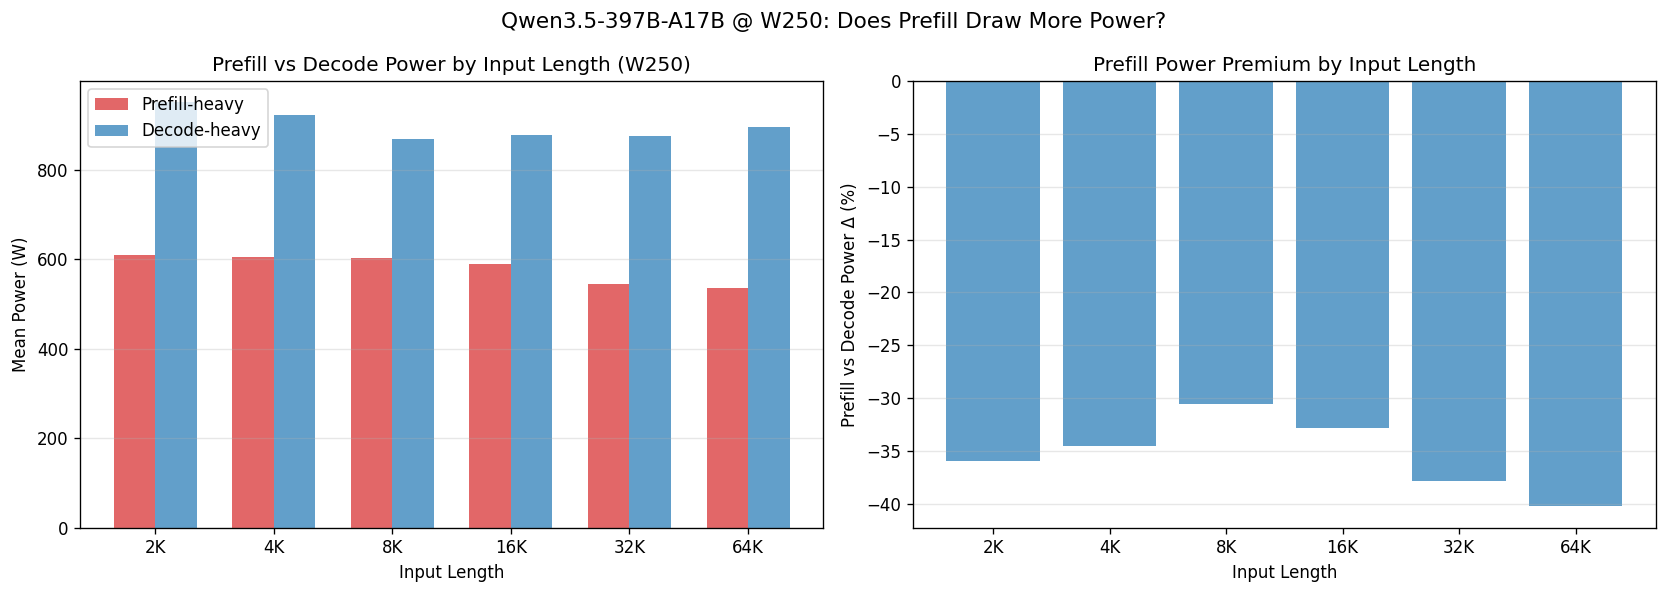

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = range(len(df_phase))
width = 0.35
ax.bar([i - width/2 for i in x], df_phase.prefill_mean_w, width, label='Prefill-heavy', color='tab:red', alpha=0.7)
ax.bar([i + width/2 for i in x], df_phase.decode_mean_w, width, label='Decode-heavy', color='tab:blue', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{il//1024}K' for il in df_phase.input_len])
ax.set_xlabel('Input Length')
ax.set_ylabel('Mean Power (W)')
ax.set_title('Prefill vs Decode Power by Input Length (W250)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x, df_phase.delta_pct, color=['tab:red' if d > 0 else 'tab:blue' for d in df_phase.delta_pct], alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels([f'{il//1024}K' for il in df_phase.input_len])
ax.set_xlabel('Input Length')
ax.set_ylabel('Prefill vs Decode Power Δ (%)')
ax.set_title('Prefill Power Premium by Input Length')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Qwen3.5-397B-A17B @ W250: Does Prefill Draw More Power?', fontsize=13)
fig.tight_layout()
plt.show()

## 7. Full throughput scaling curves: W250 vs W300

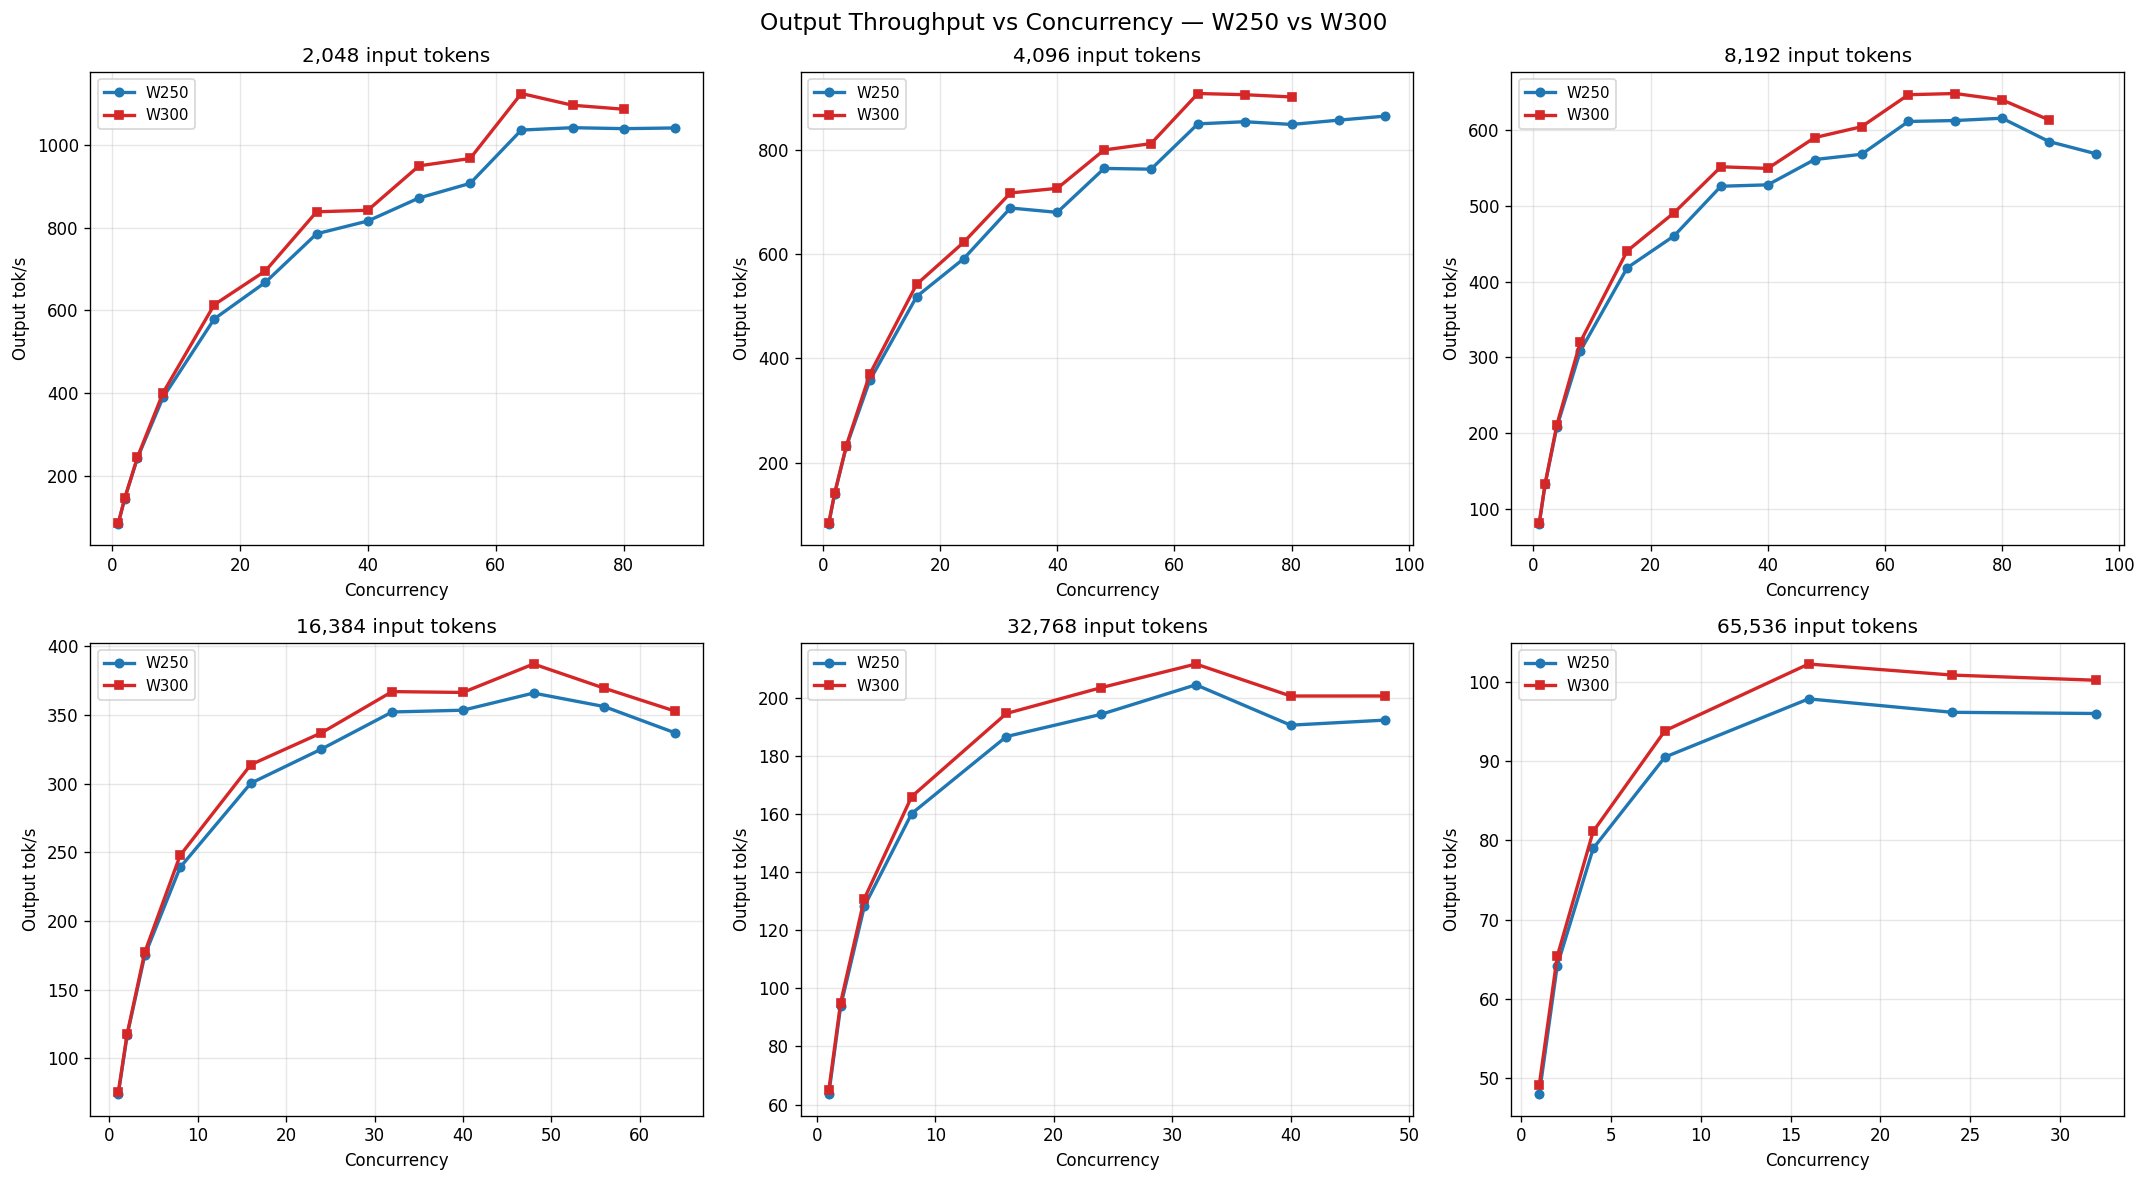

In [10]:
input_lens = sorted(df_full.input_len.unique())
n = len(input_lens)
cols = 3
rows_n = (n + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(18, 5 * rows_n))
fig.suptitle('Output Throughput vs Concurrency — W250 vs W300', fontsize=14)

for idx, input_len in enumerate(input_lens):
    ax = axes.flat[idx]
    for watt, color, marker in [(250, 'tab:blue', 'o'), (300, 'tab:red', 's')]:
        subset = df_full[(df_full.watt == watt) & (df_full.input_len == input_len)].sort_values('concurrency')
        if len(subset) > 0:
            ax.plot(subset.concurrency, subset.output_tps, f'{marker}-', color=color,
                    linewidth=2, label=f'W{watt}', markersize=5)
    ax.set_title(f'{input_len:,} input tokens')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel('Output tok/s')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for idx in range(n, len(axes.flat)):
    axes.flat[idx].set_visible(False)

fig.tight_layout()
plt.show()

## 8. Latency comparison at matched concurrency

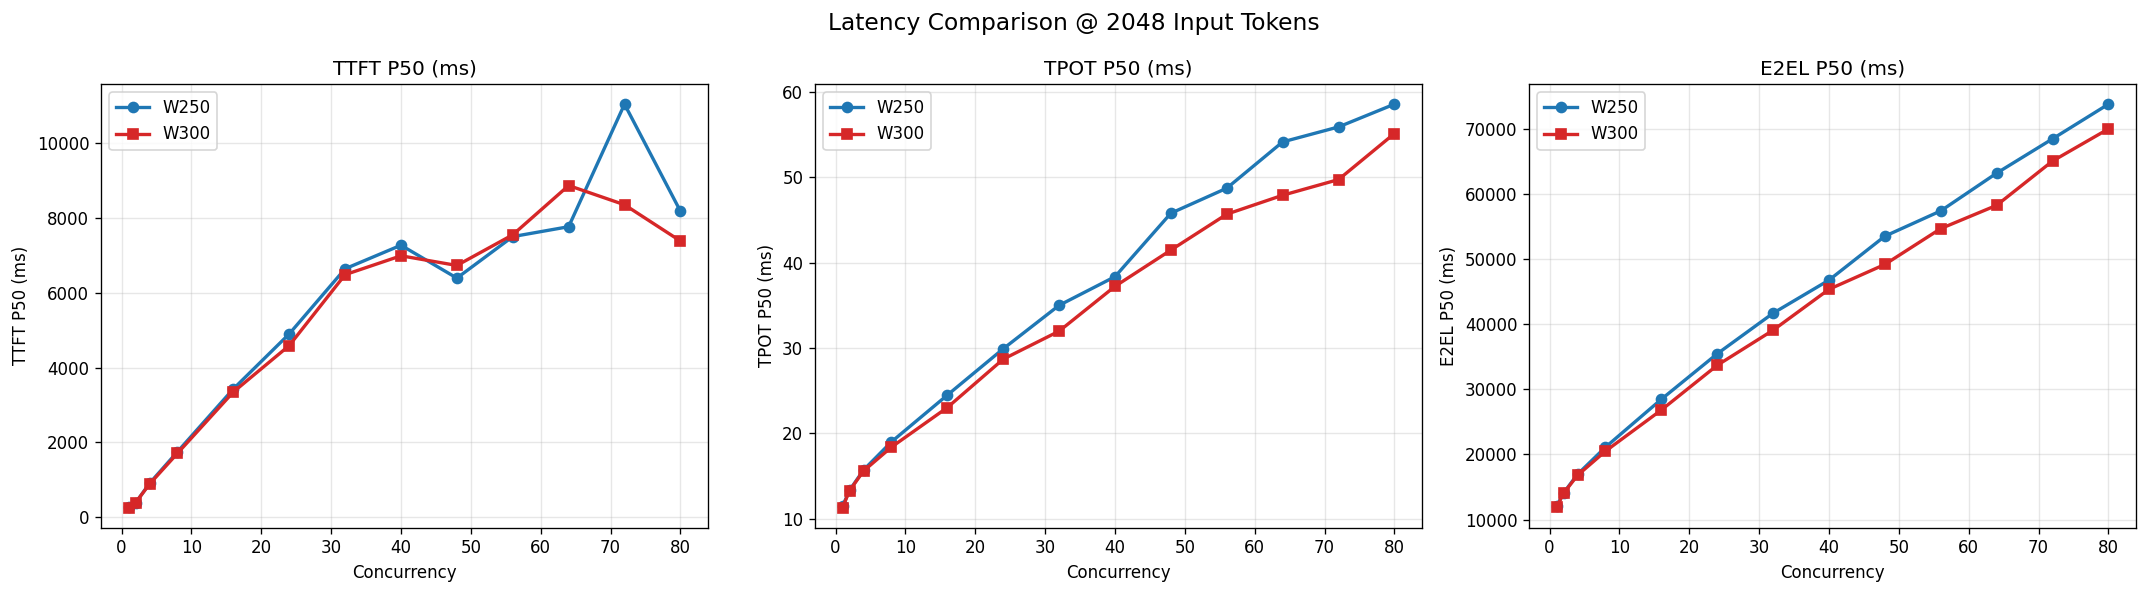

In [11]:
# Compare latency metrics at common concurrency levels for 2048in
input_len = 2048
w250 = df_full[(df_full.watt == 250) & (df_full.input_len == input_len)].set_index('concurrency')
w300 = df_full[(df_full.watt == 300) & (df_full.input_len == input_len)].set_index('concurrency')
common_conc = sorted(set(w250.index) & set(w300.index))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Latency Comparison @ {input_len} Input Tokens', fontsize=14)

for ax, metric, label in [
    (axes[0], 'ttft_p50', 'TTFT P50 (ms)'),
    (axes[1], 'tpot_p50', 'TPOT P50 (ms)'),
    (axes[2], 'e2el_p50', 'E2EL P50 (ms)'),
]:
    ax.plot(common_conc, [w250.loc[c, metric] for c in common_conc], 'o-',
            color='tab:blue', linewidth=2, label='W250')
    ax.plot(common_conc, [w300.loc[c, metric] for c in common_conc], 's-',
            color='tab:red', linewidth=2, label='W300')
    ax.set_xlabel('Concurrency')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 9. Summary

In [12]:
print('=== W250 vs W300 Summary (Qwen3.5-397B-A17B) ===')
print()

for input_len in sorted(df_full.input_len.unique()):
    vals = {}
    for watt in [250, 300]:
        subset = df_full[(df_full.watt == watt) & (df_full.input_len == input_len)]
        if len(subset) > 0:
            best_idx = subset.output_tps.idxmax()
            best = subset.loc[best_idx]
            vals[watt] = best
    
    if 250 in vals and 300 in vals:
        tps_250 = vals[250].output_tps
        tps_300 = vals[300].output_tps
        pwr_250 = vals[250].mean_power_w if pd.notna(vals[250].mean_power_w) else 0
        pwr_300 = vals[300].mean_power_w if pd.notna(vals[300].mean_power_w) else 0
        eff_250 = tps_250 / pwr_250 if pwr_250 > 0 else 0
        eff_300 = tps_300 / pwr_300 if pwr_300 > 0 else 0
        
        print(f'{input_len:>6d} input tokens:')
        print(f'  Throughput:  W250={tps_250:>7.1f} tok/s @c{int(vals[250].concurrency)}  '
              f'W300={tps_300:>7.1f} tok/s @c{int(vals[300].concurrency)}  '
              f'Δ={((tps_300-tps_250)/tps_250)*100:+.1f}%')
        if pwr_250 > 0 and pwr_300 > 0:
            print(f'  Power:       W250={pwr_250:>7.0f} W     W300={pwr_300:>7.0f} W     '
                  f'Δ={((pwr_300-pwr_250)/pwr_250)*100:+.1f}%')
            print(f'  Efficiency:  W250={eff_250:>7.2f} tok/s/W  W300={eff_300:>7.2f} tok/s/W  '
                  f'Δ={((eff_300-eff_250)/eff_250)*100:+.1f}%')
        print()

=== W250 vs W300 Summary (Qwen3.5-397B-A17B) ===

  2048 input tokens:
  Throughput:  W250= 1041.3 tok/s @c72  W300= 1123.8 tok/s @c64  Δ=+7.9%
  Power:       W250=    913 W     W300=   1062 W     Δ=+16.4%
  Efficiency:  W250=   1.14 tok/s/W  W300=   1.06 tok/s/W  Δ=-7.2%

  4096 input tokens:
  Throughput:  W250=  864.7 tok/s @c96  W300=  908.0 tok/s @c64  Δ=+5.0%
  Power:       W250=    895 W     W300=   1034 W     Δ=+15.6%
  Efficiency:  W250=   0.97 tok/s/W  W300=   0.88 tok/s/W  Δ=-9.2%

  8192 input tokens:
  Throughput:  W250=  615.9 tok/s @c80  W300=  648.6 tok/s @c72  Δ=+5.3%
  Power:       W250=    866 W     W300=    991 W     Δ=+14.5%
  Efficiency:  W250=   0.71 tok/s/W  W300=   0.65 tok/s/W  Δ=-8.0%

 16384 input tokens:
  Throughput:  W250=  365.8 tok/s @c48  W300=  387.0 tok/s @c48  Δ=+5.8%
  Power:       W250=    838 W     W300=    947 W     Δ=+12.9%
  Efficiency:  W250=   0.44 tok/s/W  W300=   0.41 tok/s/W  Δ=-6.3%

 32768 input tokens:
  Throughput:  W250=  204.5 tok/s

In [ ]:
def save(fig, name):
    path = os.path.join(PLOT_DIR, f'{name}.png')
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

# --- 1) Peak throughput + power by input length ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for watt, color, marker in [(250, 'tab:blue', 'o'), (300, 'tab:red', 's')]:
    p = peak[peak.watt == watt].sort_values('input_len')
    axes[0].plot(p.input_len, p.output_tps, f'{marker}-', color=color, linewidth=2, label=f'W{watt}', markersize=8)
    axes[1].plot(p.input_len, p.mean_power_w, f'{marker}-', color=color, linewidth=2, label=f'W{watt}', markersize=8)
axes[0].set_title('Peak Output Throughput by Input Length')
axes[0].set_xlabel('Input Length (tokens)'); axes[0].set_ylabel('Output tok/s')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_xscale('log', base=2)
axes[1].set_title('Mean Power at Peak Throughput')
axes[1].set_xlabel('Input Length (tokens)'); axes[1].set_ylabel('System Power (W)')
axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_xscale('log', base=2)
fig.suptitle('Qwen3.5-397B-A17B: W250 vs W300', fontsize=14)
fig.tight_layout()
save(fig, 'w250_vs_w300_throughput_power')
plt.close(fig)

# --- 2) Prefill vs decode power ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
x = range(len(df_phase))
width = 0.35
ax.bar([i - width/2 for i in x], df_phase.prefill_mean_w, width, label='Ramp-up (prefill-heavy)', color='tab:red', alpha=0.7)
ax.bar([i + width/2 for i in x], df_phase.decode_mean_w, width, label='Steady-state (decode-heavy)', color='tab:blue', alpha=0.7)
ax.set_xticks(list(x)); ax.set_xticklabels([f'{il//1024}K' for il in df_phase.input_len])
ax.set_xlabel('Input Length'); ax.set_ylabel('Mean Power (W)')
ax.set_title('Prefill vs Decode Power by Input Length (W250)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax = axes[1]
ax.bar(x, df_phase.delta_pct, color=['tab:red' if d > 0 else 'tab:blue' for d in df_phase.delta_pct], alpha=0.7)
ax.set_xticks(list(x)); ax.set_xticklabels([f'{il//1024}K' for il in df_phase.input_len])
ax.set_xlabel('Input Length'); ax.set_ylabel('Ramp-up vs Steady-state Power Δ (%)')
ax.set_title('Power Delta by Input Length'); ax.axhline(y=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')
fig.suptitle('Qwen3.5-397B-A17B @ W250: Power by Run Phase', fontsize=13)
fig.tight_layout()
save(fig, 'prefill_vs_decode_power')
plt.close(fig)

# --- 3) Efficiency (tok/s/W) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Power Efficiency (tok/s/W) vs Concurrency — W250 vs W300', fontsize=14)
for idx, il in enumerate(sorted(df_eff.input_len.unique())):
    ax = axes.flat[idx]
    for watt, color in [(250, 'tab:blue'), (300, 'tab:red')]:
        subset = df_eff[(df_eff.watt == watt) & (df_eff.input_len == il)].sort_values('concurrency')
        if len(subset) > 0:
            ax.plot(subset.concurrency, subset.efficiency, 'o-', color=color, linewidth=2, label=f'W{watt}')
    ax.set_title(f'{il:,} input tokens'); ax.set_xlabel('Concurrency'); ax.set_ylabel('tok/s/W')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.tight_layout()
save(fig, 'w250_vs_w300_efficiency')
plt.close(fig)

print(f'\nAll charts exported to {PLOT_DIR}/')